I'm putting all the code for the report figures in this folder, just for some order

In [ ]:
import pandas as pd
import glob


train_ds=pd.read_csv("C:/Users/franc/.cache/kagglehub/competitions/plant-pathology-2021-fgvc8/train.csv")

train_ds.head()
multiplesplit = [1!=len(l.split()) for l in train_ds["labels"]]
train_ds["labels"][multiplesplit].head()
print(sum(multiplesplit))
print(len(train_ds))
print(sum(train_ds["labels"]=="healthy"))

file_paths=glob.glob("C:/Users/franc/.cache/kagglehub/competitions/plant-pathology-2021-fgvc8/*")
file_paths
from pathlib import Path
import random

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt


def sample_and_plot_image_sizes(image_dir, n=200, seed=42):
    image_dir = Path(image_dir)

    jpg_files = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.jpeg")) + \
                list(image_dir.glob("*.JPG")) + list(image_dir.glob("*.JPEG"))

    if len(jpg_files) == 0:
        raise FileNotFoundError(f"No JPG/JPEG images found in {image_dir}")

    random.seed(seed)
    sampled_files = random.sample(jpg_files, min(n, len(jpg_files)))

    records = []

    for img_path in sampled_files:
        with Image.open(img_path) as img:
            width, height = img.size

        records.append({
            "filename": img_path.name,
            "width": width,
            "height": height,
            "megapixels": (width * height) / 1_000_000,
        })

    df_sizes = pd.DataFrame(records)

    print(df_sizes.head())
    print("\nSummary:")
    print(df_sizes[["width", "height", "megapixels"]].describe())

    # Plot width vs height
    f1=plt.figure(figsize=(7, 5))
    plt.scatter(df_sizes["width"], df_sizes["height"], alpha=0.6)
    plt.xlabel("Width (pixels)")
    plt.ylabel("Height (pixels)")
    plt.title(f"Image sizes for {len(df_sizes)} sampled JPG images")
    plt.grid(True)
    plt.show()
    
    f1.savefig("image_size_distribution.png")

    # Plot megapixel distribution
    plt.figure(figsize=(7, 5))
    plt.hist(df_sizes["megapixels"], bins=20, alpha=0.8)
    plt.xlabel("Megapixels")
    plt.ylabel("Number of images")
    plt.title("Distribution of sampled image sizes")
    plt.grid(True)
    plt.show()

    return df_sizes
image_dir = "C:\\Users\\franc\\.cache\\kagglehub\\competitions\\plant-pathology-2021-fgvc8\\train_images"

df_sizes = sample_and_plot_image_sizes(
    image_dir=image_dir,
    n=18000,
    seed=42,
)

    trial  num_layers  num_filters  kernel_size  dropout_rate  \
0       1           4          128            3           0.5   
1       2           2          128            5           0.4   
2       3           2           32            3           0.1   
3       4           2           64            7           0.3   
4       5           2           16            7           0.4   
5       6           2           64            5           0.2   
6       7           3           16            3           0.1   
7       8           4           16            3           0.4   
8       9           3           16            3           0.2   
9      10           2           32            3           0.5   
10     11           3           16            5           0.1   
11     12           2           64            3           0.1   
12     13           4           32            7           0.5   
13     14           2           16            3           0.3   
14     15           3    

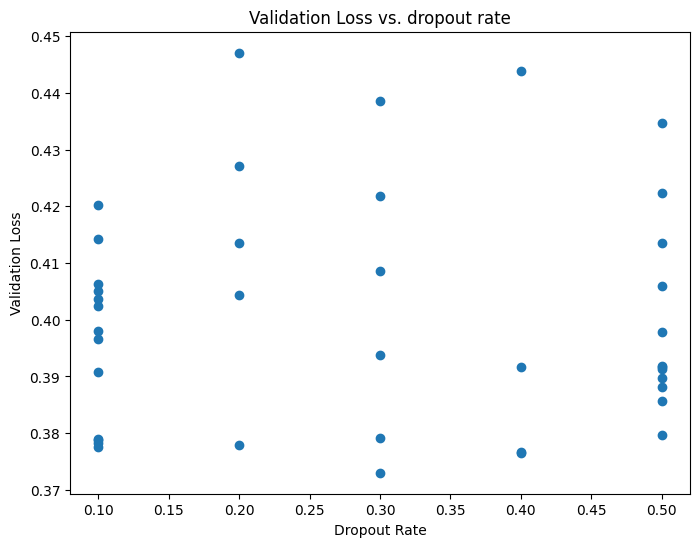

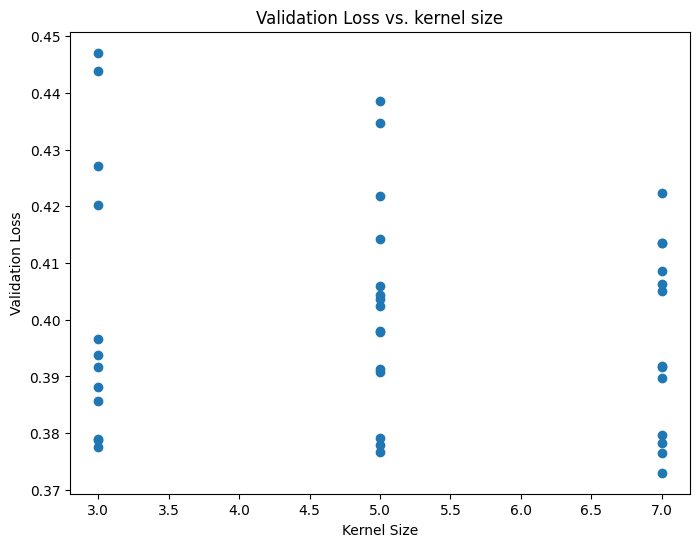

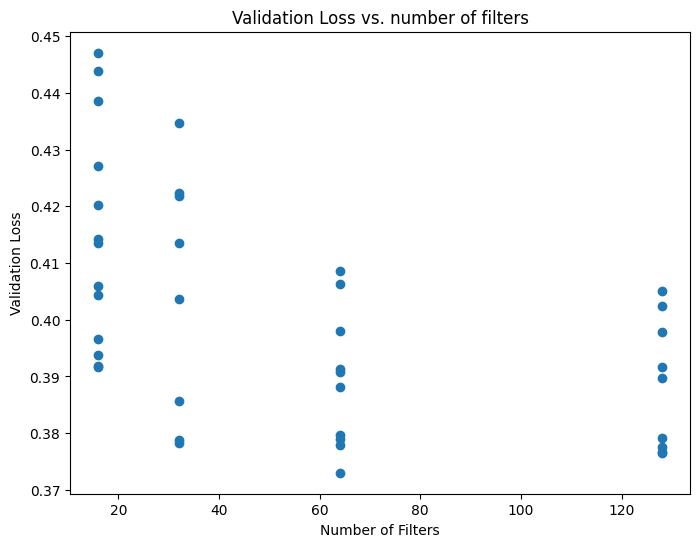

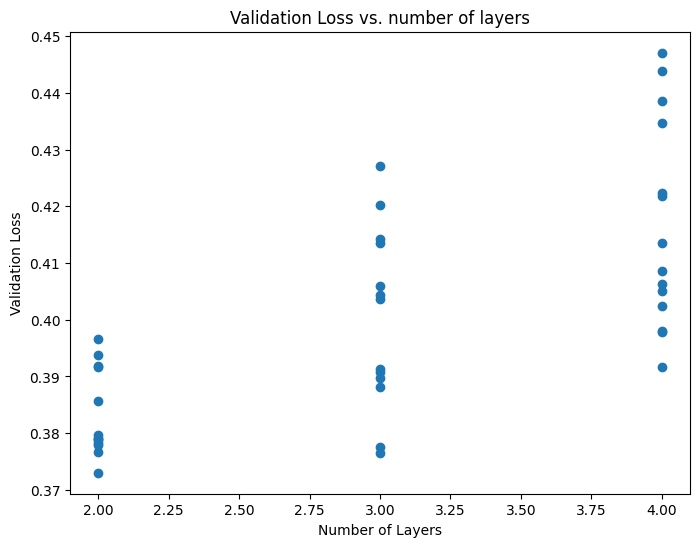

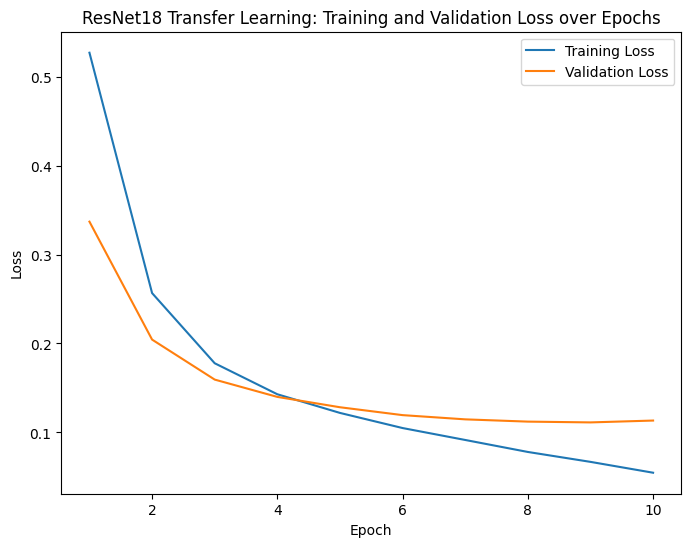

In [ ]:
prev_results=pd.read_csv("random_search_results.csv")
print(prev_results)
already_seen = prev_results[["num_layers", "num_filters", "kernel_size", "dropout_rate"]].values.tolist()

import matplotlib.pyplot as plt
import seaborn as sns

f1=plt.figure(figsize=(8, 6))
plt.title("Validation Loss vs. dropout rate")
plt.xlabel("Dropout Rate")
plt.ylabel("Validation Loss")
plt.scatter(x=prev_results["dropout_rate"], y= prev_results["best_trial_val_loss"])
plt.show()
f1.savefig("val_loss_vs_dropout_rate.png")

f2=plt.figure(figsize=(8, 6))
plt.title("Validation Loss vs. kernel size")
plt.xlabel("Kernel Size")
plt.ylabel("Validation Loss")
plt.scatter(x=prev_results["kernel_size"], y= prev_results["best_trial_val_loss"])
plt.show()
f2.savefig("val_loss_vs_kernel_size.png")

f3=plt.figure(figsize=(8, 6))
plt.title("Validation Loss vs. number of filters")
plt.xlabel("Number of Filters")
plt.ylabel("Validation Loss")
plt.scatter(x=prev_results["num_filters"], y= prev_results["best_trial_val_loss"])
plt.show()
f3.savefig("val_loss_vs_num_filters.png")

f4=plt.figure(figsize=(8, 6))
plt.title("Validation Loss vs. number of layers")
plt.xlabel("Number of Layers")
plt.ylabel("Validation Loss")
plt.scatter(x=prev_results["num_layers"], y= prev_results["best_trial_val_loss"])
plt.show()
f4.savefig("val_loss_vs_num_layers.png")

transfer_history=pd.read_csv("resnet18_transfer_history.csv")
f5=plt.figure(figsize=(8, 6))
plt.title("ResNet18 Transfer Learning: Training and Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(transfer_history["epoch"], transfer_history["train_loss"], label="Training Loss")
plt.plot(transfer_history["epoch"], transfer_history["val_loss"], label="Validation Loss")
plt.legend()
plt.show()
f5.savefig("resnet18_transfer_learning.png")

history_50_epochs=pd.read_csv("50_epoch_history.csv")

f6=plt.figure(figsize=(8, 6))
plt.title("Training and Validation Loss over 50 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss") 
plt.plot(history_50_epochs["epoch"], history_50_epochs["train_loss"], label="Training Loss")
plt.plot(history_50_epochs["epoch"], history_50_epochs["val_loss"], label=" Validation Loss")
plt.legend()
plt.show() 
f6.savefig("training_validation_loss_50_epochs.png")